# Humpback Whale Identification — ArcFace Metric Learning

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe


## ArcFace Training

**ArcFace** (Deng et al., CVPR 2019 — course slides 31–33) modifies the classification
head to enforce angular margin between classes on a hypersphere.

Instead of computing logits as `W · f(x)`, ArcFace:
1. L2-normalizes both weight vectors and embeddings
2. Computes cosine similarity (= angular distance on the hypersphere)
3. Adds an angular penalty `m` to the correct class's angle
4. Scales by factor `s` before softmax

This forces the model to cluster same-class embeddings tightly and push different
classes apart by at least `m` radians. The key advantage over triplet loss:
**no pair/triplet mining is needed** — ArcFace works with standard batching (slide 31).

We initialize from the baseline's backbone + embedding weights, replacing only
the classifier head with the ArcFace head.


## Setup & Imports

In [9]:
import sys
import os
import torch
import json
from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from visualization import plot_embedding_tsne


sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import (
    prepare_data,
    build_dataloaders,
 )
from models import build_model
from training import train
from visualization import plot_training_history

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX PRO 4000 Blackwell


## Experiment Configuration

In [10]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="arcface_effnetb5",
    description="ArcFace angular margin loss, initialized from baseline",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,
    head_type="arcface",       # ← ArcFace head instead of linear
    arcface_scale=30.0,        # Logit scale factor
    arcface_margin=0.5,        # Angular margin (radians)

    # ── Training ─────────────────────────────────────────────────
    freeze_backbone_epochs=3,  # Shorter freeze: backbone is already good from baseline
    freeze_bn=True,
    epochs=35,
    batch_size=16,
    accumulation_steps=2,
    use_amp=False,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=5e-4,              # Slightly lower than baseline (fine-tuning, not fresh)
    lr_backbone=5e-5,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="arcface_ce",    # Standard CE on the ArcFace-modified logits
    label_smoothing=0.0,       # No label smoothing with ArcFace (margin handles it)
    use_class_weights=False,   # ArcFace margin handles class separation

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=3,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Initialize from baseline ─────────────────────────────────
    # UPDATE THIS PATH to your best baseline checkpoint:
    init_from_checkpoint=BASELINE_CHECKPOINT if 'BASELINE_CHECKPOINT' in dir() else None,

    seed=42,
)

print("ArcFace config:")
print(config.summary())

print(f"init_from_checkpoint: {config.init_from_checkpoint}")


ArcFace config:
efficientnet_b5 | 456px | arcface_ce(γ=2.0) | lr=5e-05/0.0005 | freeze=3ep | bs=16×2 | head=arcface(s=30.0,m=0.5)
init_from_checkpoint: None


## Data Preparation

In [11]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

In [12]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260527_171122_arcface_effnetb5_2bb8ad39"

if TRAINING_ENABLED:
    #manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)

Skipping training


## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


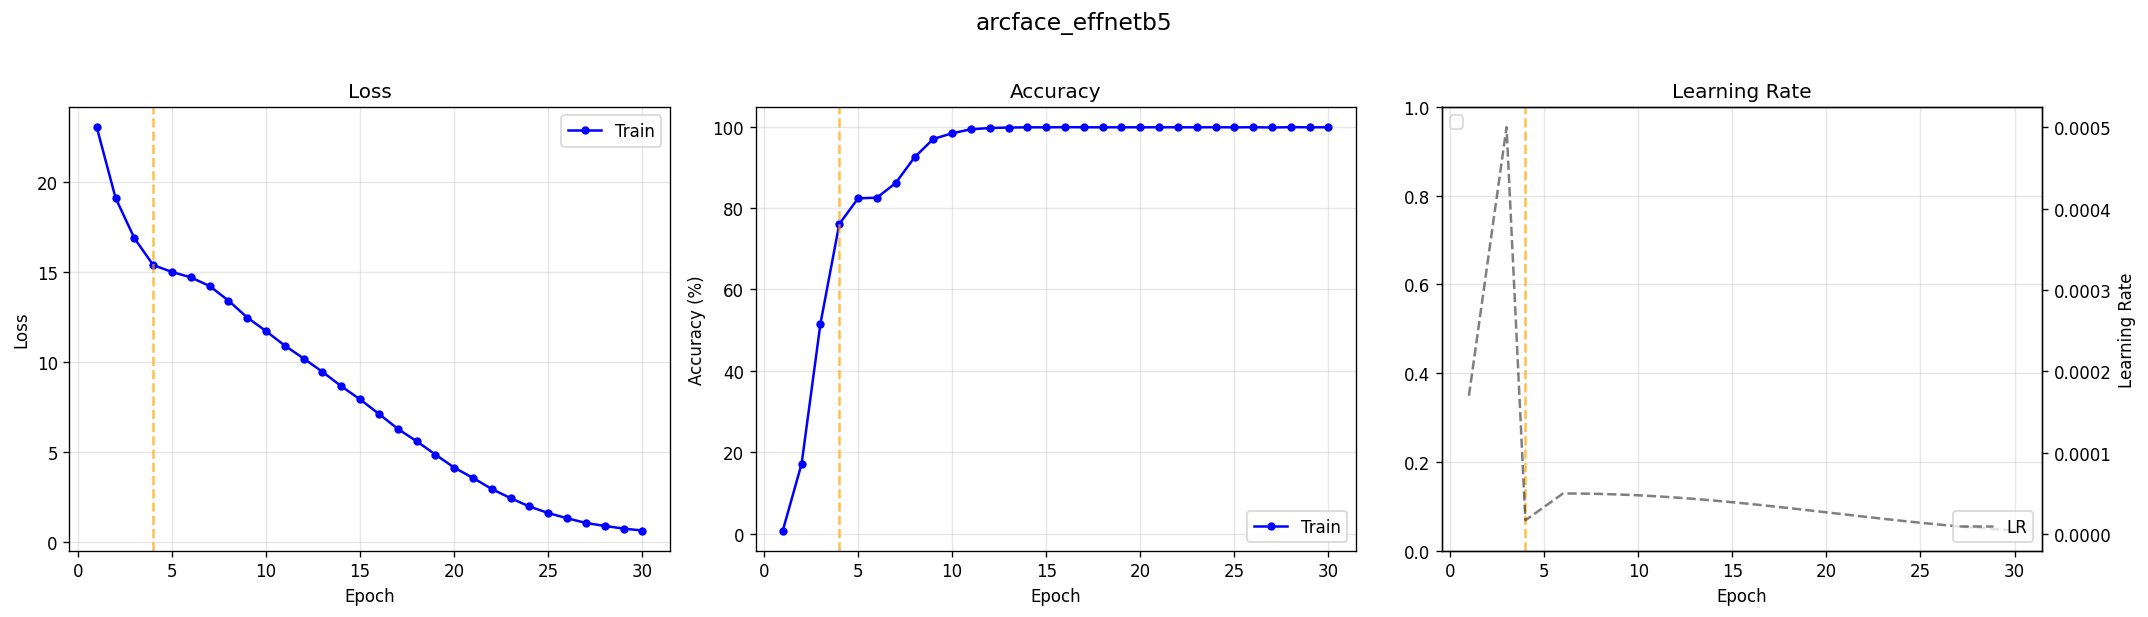

In [13]:
metrics_path = manager.root / "metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)

In [14]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "train_acc", "known_recall@1", 
            "known_recall@5", "mean_known_conf", "mean_new_whale_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.6350
  train_acc                     : 99.85%
  known_recall@1                : 0.6515
  known_recall@5                : 0.7328
  mean_known_conf               : 0.6721
  mean_new_whale_conf           : 0.6372


## Evaluate Best Model

### Using Arcface classifier (templates)

In [15]:
from final_evaluation import evaluate_base_metrics, get_classifier_predictions, get_retrieval_predictions

# Load best model
config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
model = build_model(config, data["num_classes"], device)
state = torch.load("experiments/" + EXPERIMENT_ID + "/checkpoints/best.pth", map_location=device, weights_only=False)
model_state = state.get("model_state_dict", state)
model.load_state_dict(model_state)
model.eval()

# Run evaluation
#criterion = build_loss(config, data["class_counts"], device)
eval_config, data = get_eval_config_and_data()
gallery_loader, query_loader = build_retrieval_eval_loaders(eval_config, data)
scores, predictions, labels = get_classifier_predictions(model, query_loader, device, 5)
val_metrics = evaluate_base_metrics(scores, predictions, labels)

print("\nBest model classification validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)


Extracting Classifier Preds:   0%|          | 0/51 [00:00<?, ?it/s]


Best model classification validation metrics:
  known_recall@1                : 0.6429
  known_recall@5                : 0.7340
  mean_known_conf               : 0.6259
  mean_new_whale_conf           : 0.5138


### Using Arcface retrieval

In [16]:
scores, predictions, labels = get_retrieval_predictions(model, gallery_loader, query_loader, device, 5)
val_metrics = evaluate_base_metrics(scores, predictions, labels)

print("\nBest model retrieval validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

Computing k-NN:   0%|          | 0/3 [00:00<?, ?it/s]


Best model retrieval validation metrics:
  known_recall@1                : 0.6539
  known_recall@5                : 0.7291
  mean_known_conf               : 0.6823
  mean_new_whale_conf           : 0.6519


## Embedding Quality


  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

t-SNE: 224 points, 10 classes (min 5/class)


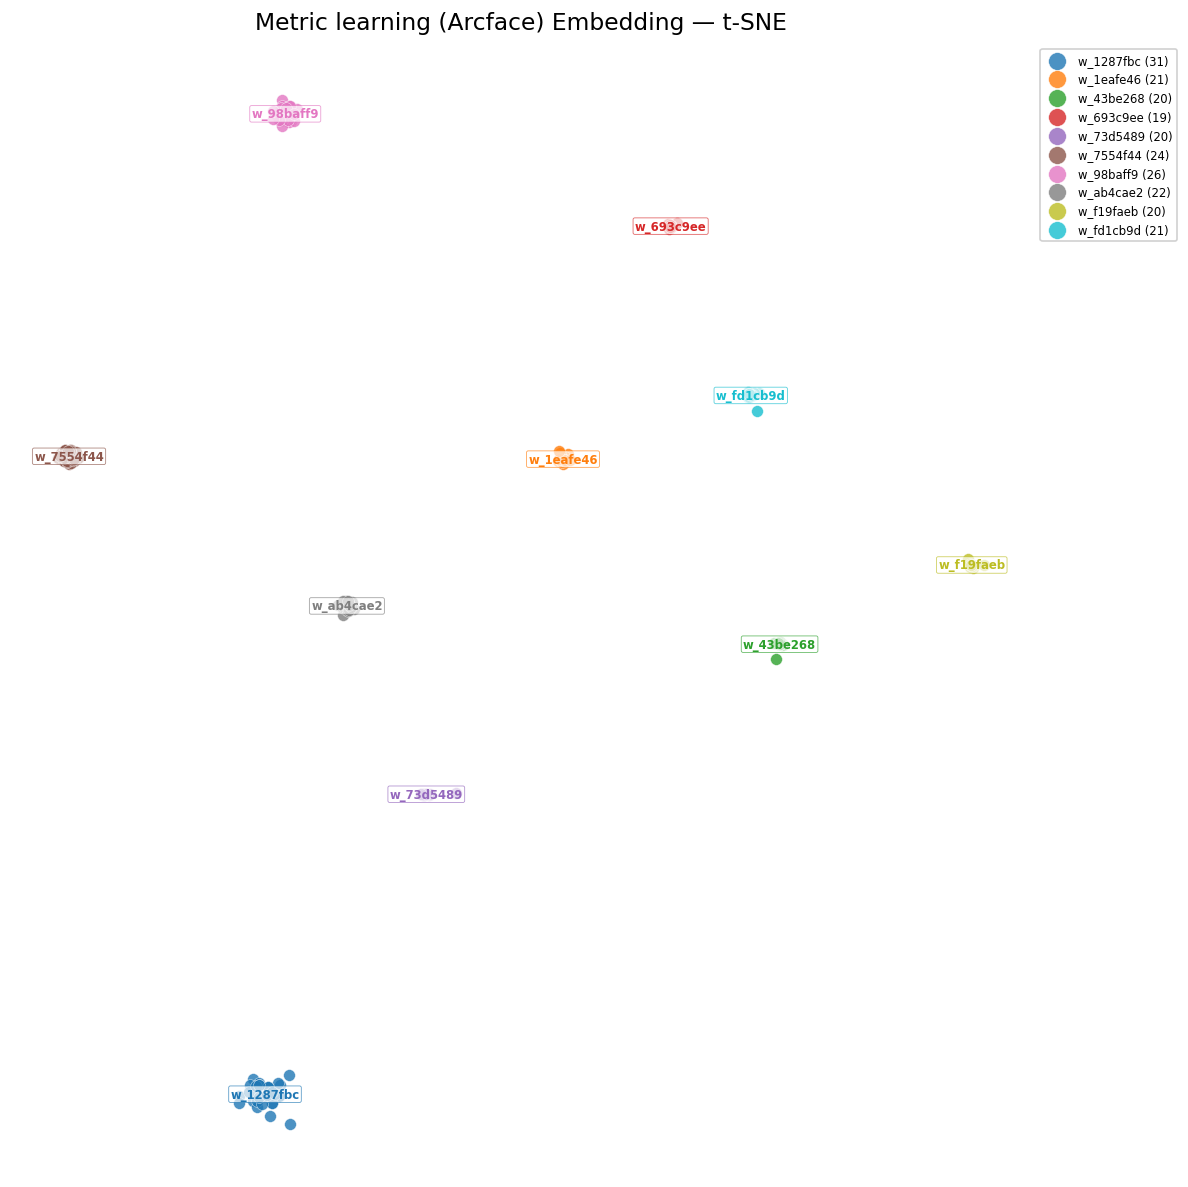

  Perplexity used: 28 | KL divergence: 0.04


In [17]:
# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
from visualization import plot_embedding_tsne

if model is not None:
    plot_embedding_tsne(
        model, query_loader, data, device,
        title="Metric learning (Arcface) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[gallery_loader],
    )